# Living Environment Deprivation with AlphaEarth Embeddings

This notebook prepares polygon-level AlphaEarth features for London LSOAs, builds a borough-grouped train/validation/test split, and compares a mean predictor, XGBoost, and a 2-layer GAT for Living Environment deprivation regression.


## Reproducibility notes

This notebook is organised to run sequentially from top to bottom.

Before running the notebook, please download dataset, including:

- `alphaearth_polygon_mean_std_2024.csv`
- `env_deprivation.csv`
- `lsoas_p_2021_env_polygon_mean_std.gpkg`
- the `Boundary` folder

After downloading, please save them locally and either place them into the expected project folders or update the file paths in the notebook to match your local directory structure before execution.

Google Earth Engine access is required only for the AlphaEarth extraction section only. If you dont want to use API, I have prepared a downloaded version, and please skip the Step 2.1


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Check Ground Truth

## 1. Prepare the target dataset

In [2]:
# Load London LSOA boundaries, prepare the Living Environment Deprivation target, and merge it into the spatial table.
lsoas = gpd.read_file("data/London_LSOA21.shp")

env = pd.read_csv( "data/env_deprivation.csv")
env = env.rename(columns={
    "LSOA code (2021)": "lsoa_code",
    "LSOA name (2021)": "lsoa_name",
    "Living Environment Rank (where 1 is most deprived)": "living_env_rank",
    "Living Environment Decile (where 1 is most deprived 10% of LSOAs)": "living_env_decile"
})

N_ENGLAND_LSOA = 33755
env["living_env_percentile"] = 1 - (env["living_env_rank"] - 1) / (N_ENGLAND_LSOA - 1)

env_small = env[[
    "lsoa_code",
    "lsoa_name",
    "living_env_rank",
    "living_env_decile",
    "living_env_percentile"
]].copy()

merged = lsoas.merge(
    env_small,
    left_on="lsoa21cd",
    right_on="lsoa_code",
    how="left"
)

print("lsoas shape:", lsoas.shape)
print("env shape:", env.shape)
print("merged shape:", merged.shape)
print("unmatched rows:", int(merged["living_env_rank"].isna().sum()))

merged[[
    "lsoa21cd",
    "lsoa21nm",
    "living_env_rank",
    "living_env_decile",
    "living_env_percentile"
]].head()

lsoas shape: (4994, 8)
env shape: (33755, 5)
merged shape: (4994, 13)
unmatched rows: 0


,lsoa21cd,lsoa21nm,living_env_rank,living_env_decile,living_env_percentile
0,E01000011,Barking and Dagenham 016C,1226,1,0.963708
1,E01000046,Barking and Dagenham 017D,14190,5,0.579635
2,E01000051,Barking and Dagenham 021D,10529,4,0.688096
3,E01000077,Barking and Dagenham 008F,7518,3,0.777300
4,E01000083,Barking and Dagenham 007F,6881,3,0.796172


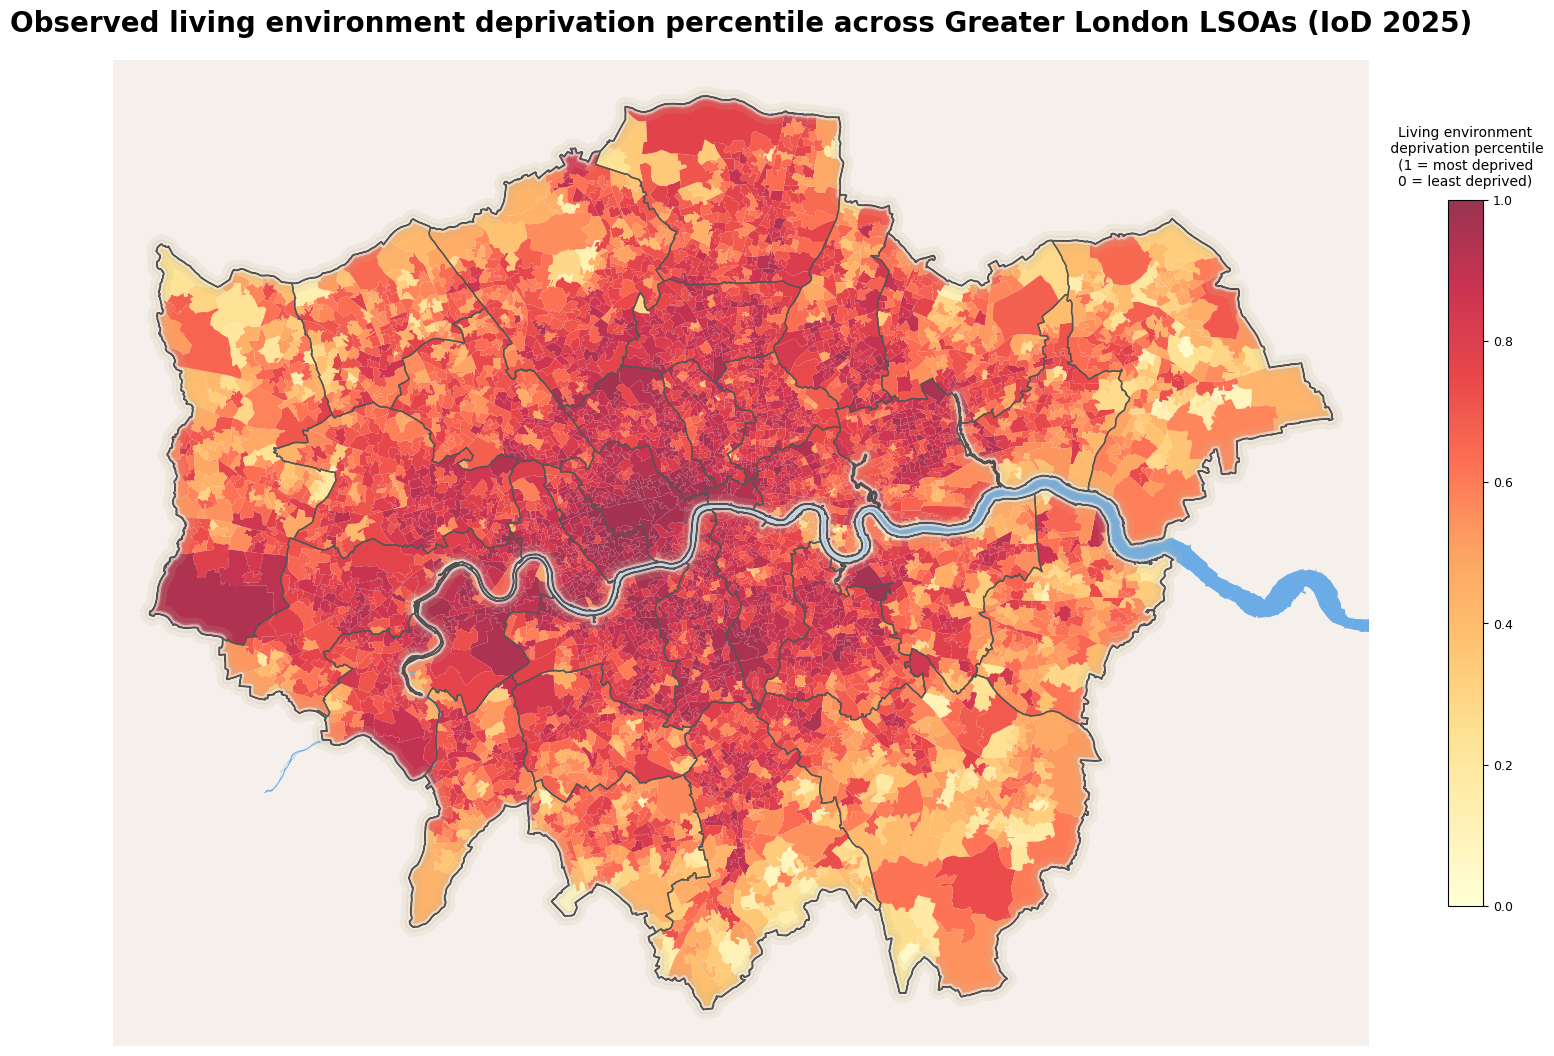

In [3]:

PLOT_CRS = "EPSG:27700"

borough = gpd.read_file("data/London_Borough.shp").to_crs(PLOT_CRS)
river = gpd.read_file( "data/river.shp").to_crs(PLOT_CRS)
background = gpd.read_file("data/background_london.shp").to_crs(PLOT_CRS)

ground_truth = merged.to_crs(PLOT_CRS).copy()

name_col = "BOROUGHN"
borough_diss = borough.dissolve(by=name_col, as_index=False)
london_outline = borough_diss.dissolve()
bg_outside = gpd.overlay(background, london_outline, how="difference")

base_cmap = plt.colormaps.get_cmap("YlOrRd")
colors = base_cmap(np.linspace(0, 1, 256))
blend = 0.20
colors[:, :3] = colors[:, :3] * (1 - blend) + 1.0 * blend

soft_ylorrd = mcolors.LinearSegmentedColormap.from_list("soft_YlOrRd", colors)


fig, ax = plt.subplots(figsize=(16, 16), facecolor="white")

bg_outside.plot(
    ax=ax,
    facecolor="#f5f0eb",
    edgecolor="black",
    linewidth=0.10,
    zorder=1
)

ground_truth.plot(
    column="living_env_percentile",
    cmap=soft_ylorrd,
    vmin=0,
    vmax=1,
    edgecolor="none",
    linewidth=0,
    legend=True,
    ax=ax,
    zorder=2,
    legend_kwds={"shrink": 0.45, "orientation": "vertical"}
)

river.plot(
    ax=ax,
    facecolor="#6BACE6",
    edgecolor="none",
    linewidth=0,
    zorder=3
)

london_outline.boundary.plot(ax=ax, color="#c8b89a", linewidth=14, alpha=0.15, zorder=3.3)
london_outline.boundary.plot(ax=ax, color="#c8b89a", linewidth=7, alpha=0.25, zorder=3.4)
london_outline.boundary.plot(ax=ax, color="#f5f5f5", linewidth=4.5, alpha=0.55, zorder=3.8)
london_outline.boundary.plot(ax=ax, color="black", linewidth=1.1, alpha=0.9, zorder=3.9)

borough_diss.boundary.plot(
    ax=ax,
    color="#555555",
    linewidth=1,
    alpha=1,
    zorder=4
)

ax.set_title(
    "Observed living environment deprivation percentile across Greater London LSOAs (IoD 2025)",
    fontsize=20,
    pad=20,
    fontweight="bold"
)
ax.set_axis_off()

cax = fig.axes[-1]
ticks = np.arange(0, 1.01, 0.2)
cax.set_yticks(ticks)
cax.set_yticklabels([f"{t:.1f}" for t in ticks])
cax.set_title(
    "Living environment\n deprivation percentile\n(1 = most deprived\n0 = least deprived)",
    fontsize=10,
    pad=10
)
cax.tick_params(labelsize=9)

xmin, ymin, xmax, ymax = borough_diss.total_bounds
pad = 1800
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
#fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
#print(f"Saved to: {save_path}")
plt.show()



In [4]:
# Prepare GeoDataFrame
gdf = merged.dropna(subset=["living_env_percentile"]).copy()
gdf_wgs84 = gdf.to_crs(4326).copy()

print("Matched LSOAs:", len(gdf_wgs84))
print("CRS:", gdf_wgs84.crs)
print(gdf_wgs84[[
    "lsoa21cd",
    "lsoa21nm",
    "living_env_rank",
    "living_env_percentile"
]].head())

Matched LSOAs: 4994
CRS: EPSG:4326
    lsoa21cd                   lsoa21nm  living_env_rank  \
0  E01000011  Barking and Dagenham 016C             1226   
1  E01000046  Barking and Dagenham 017D            14190   
2  E01000051  Barking and Dagenham 021D            10529   
3  E01000077  Barking and Dagenham 008F             7518   
4  E01000083  Barking and Dagenham 007F             6881   

   living_env_percentile  
0               0.963708  
1               0.579635  
2               0.688096  
3               0.777300  
4               0.796172  


In [5]:
# Build London geometry
bounds = gdf_wgs84.union_all().bounds
print("London bounds:", bounds)

London bounds: (-0.510357608969102, 51.28675862708375, 0.3340430025029236, 51.691876996183055)


# 2.1 Skip this if you dont want to use APIExtract AlphaEarth embeddings 
This section aggregates the 2024 Google AlphaEarth embedding mosaic over LSOA polygons using mean and standard deviation

In [ ]:
import ee

ee.Authenticate()

ee.Initialize(project="geoai-london-deprivation")

gdf = merged.dropna(subset=["living_env_percentile"]).copy()
gdf_wgs84 = gdf.to_crs(4326).copy()

bounds = gdf_wgs84.union_all().bounds
london_geometry = ee.Geometry.Rectangle(list(bounds))

print("Original CRS:", gdf.crs)
print("EE CRS:", gdf_wgs84.crs)
print("LSOAs:", len(gdf_wgs84))
print(gdf_wgs84[["lsoa21cd", "geometry"]].head())
print("London bounds:", bounds)

In [ ]:
# Get AlphaEarth 2024 image
embedding_collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

year_filtered = (
    embedding_collection
    .filterDate("2024-01-01", "2024-12-31")
    .filterBounds(london_geometry)
)

print("Number of images:", year_filtered.size().getInfo())

london_image = year_filtered.mosaic().clip(london_geometry)
band_names = london_image.bandNames().getInfo()

print("Mosaic ready.")
print("Number of bands:", len(band_names))
print(band_names)

In [ ]:
# GeoDataFrame -> Earth Engine FeatureCollection
def gdf_to_ee_fc(gdf_batch, id_col="lsoa21cd"):
    features = []
    for _, row in gdf_batch.iterrows():
        geom = ee.Geometry(row.geometry.__geo_interface__)
        feat = ee.Feature(geom, {id_col: row[id_col]})
        features.append(feat)
    return ee.FeatureCollection(features)

In [ ]:
# Extract polygon mean + stdDev embeddings
def extract_embeddings_for_batch(batch_gdf, image, band_names):
    fc = gdf_to_ee_fc(batch_gdf[["lsoa21cd", "geometry"]])

    reducer = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    )

    sampled = image.reduceRegions(
        collection=fc,
        reducer=reducer,
        scale=10
    )

    features = sampled.getInfo()["features"]
    rows = []

    for f in features:
        props = f["properties"]
        row = {"lsoa21cd": props["lsoa21cd"]}

        for band in band_names:
            row[f"{band}_mean"] = props.get(f"{band}_mean")
            row[f"{band}_stdDev"] = props.get(f"{band}_stdDev")

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
# Full extraction in batches
batch_size = 100
batches = []
n_batches = (len(gdf_wgs84) - 1) // batch_size + 1

for start in range(0, len(gdf_wgs84), batch_size):
    end = min(start + batch_size, len(gdf_wgs84))
    batch_gdf = gdf_wgs84.iloc[start:end][["lsoa21cd", "geometry"]].copy()

    print(f"Running batch {start // batch_size + 1}/{n_batches} ...")
    batch_df = extract_embeddings_for_batch(batch_gdf, london_image, band_names)
    batches.append(batch_df)

embeddings_df = pd.concat(batches, ignore_index=True)

print("Final shape:", embeddings_df.shape)
embeddings_df.head()

## 2.2 Run this if you didnt use API: Reading extracted AlphaEarth embeddings 

In [6]:
emb_path = "data/alphaearth_polygon_mean_std_2024.csv"
embeddings_df = pd.read_csv(emb_path)

print(embeddings_df.shape)
print(embeddings_df.head())

(4994, 129)
    lsoa21cd  A00_mean  A00_stdDev  A01_mean  A01_stdDev  A02_mean  \
0  E01000011 -0.142119    0.028474 -0.304375    0.037895 -0.070490   
1  E01000046 -0.079278    0.025157 -0.297655    0.027699 -0.014320   
2  E01000051 -0.024044    0.033402 -0.221388    0.053970  0.007738   
3  E01000077 -0.062033    0.046915 -0.329082    0.031582 -0.067414   
4  E01000083 -0.027204    0.035380 -0.303824    0.027944 -0.039634   

   A02_stdDev  A03_mean  A03_stdDev  A04_mean  ...  A59_mean  A59_stdDev  \
0    0.026158 -0.063109    0.042629  0.067819  ... -0.133895    0.069285   
1    0.048976 -0.096458    0.030374  0.034573  ... -0.063973    0.026920   
2    0.040794 -0.090941    0.028768  0.072661  ... -0.160937    0.040139   
3    0.042413 -0.067825    0.042779  0.066596  ... -0.058303    0.049920   
4    0.031458 -0.106695    0.029586  0.049830  ... -0.049413    0.028051   

   A60_mean  A60_stdDev  A61_mean  A61_stdDev  A62_mean  A62_stdDev  A63_mean  \
0  0.056322    0.018030  0.02

In [7]:
# Merge polygon-aggregated AlphaEarth embeddings with the London LSOA target table.
# This creates the final modelling dataset for deprivation prediction.
model_df = gdf.merge(embeddings_df, on="lsoa21cd", how="inner").copy()

print("model_df shape:", model_df.shape)
print("Missing target:", model_df["living_env_percentile"].isna().sum())

model_df[[
    "lsoa21cd",
    "lsoa21nm",
    "living_env_percentile"
]].head()

model_df shape: (4994, 141)
Missing target: 0


,lsoa21cd,lsoa21nm,living_env_percentile
0,E01000011,Barking and Dagenham 016C,0.963708
1,E01000046,Barking and Dagenham 017D,0.579635
2,E01000051,Barking and Dagenham 021D,0.688096
3,E01000077,Barking and Dagenham 008F,0.777300
4,E01000083,Barking and Dagenham 007F,0.796172


## 3. Build the modelling dataset

In [8]:
# Build final model dataset
# target = living_env_percentile
# features = 64 AlphaEarth means + 64 stdDevs

target_col = "living_env_percentile"

feature_cols = (
    [f"A{i:02d}_mean" for i in range(64)] +
    [f"A{i:02d}_stdDev" for i in range(64)]
)

lsoas_p = model_df.to_crs(4326).copy()

print("Final dataset:", len(lsoas_p), "LSOAs")
print("Feature columns present:", all(c in lsoas_p.columns for c in feature_cols))
print("Missing target:", int(lsoas_p[target_col].isna().sum()))

lsoas_p[["lsoa21cd", "lad22nm", target_col] + feature_cols[:4]].head()

Final dataset: 4994 LSOAs
Feature columns present: True
Missing target: 0


,lsoa21cd,lad22nm,living_env_percentile,A00_mean,A01_mean,A02_mean,A03_mean
0,E01000011,Barking and Dagenham,0.963708,-0.142119,-0.304375,-0.070490,-0.063109
1,E01000046,Barking and Dagenham,0.579635,-0.079278,-0.297655,-0.014320,-0.096458
2,E01000051,Barking and Dagenham,0.688096,-0.024044,-0.221388,0.007738,-0.090941
3,E01000077,Barking and Dagenham,0.777300,-0.062033,-0.329082,-0.067414,-0.067825
4,E01000083,Barking and Dagenham,0.796172,-0.027204,-0.303824,-0.039634,-0.106695


## 4. Modelling

In [9]:
# Uncomment this line if the environment is missing required packages.
# %pip install torch-geometric libpysal xgboost -q

In [10]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from libpysal.weights import Queen

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


/opt/anaconda3/envs/geoai_task2_london/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
lsoas_p = gpd.read_file("lsoas_p_2021_env_polygon_mean_std.gpkg")

FEATURE_COLS = (
    [f"A{i:02d}_mean" for i in range(64)] +
    [f"A{i:02d}_stdDev" for i in range(64)]
)

TARGET_COL = "living_env_percentile"
BOROUGH_COL = "lad22nm"

assert all(col in lsoas_p.columns for col in FEATURE_COLS), "Feature columns are missing."
assert TARGET_COL in lsoas_p.columns, "Target column is missing."
assert BOROUGH_COL in lsoas_p.columns, "Borough column is missing."

lsoas_p = lsoas_p.reset_index(drop=True)

print(f"Loaded: {len(lsoas_p)} LSOAs")
print(f"Boroughs: {lsoas_p[BOROUGH_COL].nunique()}")
print(f"Feature count: {len(FEATURE_COLS)}")

lsoas_p[[BOROUGH_COL, TARGET_COL] + FEATURE_COLS[:4]].head()

Loaded: 4994 LSOAs
Boroughs: 33
Feature count: 128


,lad22nm,living_env_percentile,A00_mean,A01_mean,A02_mean,A03_mean
0,Barking and Dagenham,0.963708,-0.142119,-0.304375,-0.070490,-0.063109
1,Barking and Dagenham,0.579635,-0.079278,-0.297655,-0.014320,-0.096458
2,Barking and Dagenham,0.688096,-0.024044,-0.221388,0.007738,-0.090941
3,Barking and Dagenham,0.777300,-0.062033,-0.329082,-0.067414,-0.067825
4,Barking and Dagenham,0.796172,-0.027204,-0.303824,-0.039634,-0.106695


In [12]:
# Borough-based grouped split
rng = np.random.default_rng(SEED)

boroughs = np.array(sorted(lsoas_p[BOROUGH_COL].unique()))
boroughs = rng.permutation(boroughs)

n_boroughs = len(boroughs)
n_test_boroughs = max(1, int(round(n_boroughs * 0.15)))
n_val_boroughs = max(1, int(round(n_boroughs * 0.15)))

test_boroughs = set(boroughs[:n_test_boroughs])
val_boroughs = set(boroughs[n_test_boroughs:n_test_boroughs + n_val_boroughs])
train_boroughs = set(boroughs[n_test_boroughs + n_val_boroughs:])

lsoas_p["split"] = "train"
lsoas_p.loc[lsoas_p[BOROUGH_COL].isin(val_boroughs), "split"] = "val"
lsoas_p.loc[lsoas_p[BOROUGH_COL].isin(test_boroughs), "split"] = "test"

train_idx = lsoas_p.index[lsoas_p["split"] == "train"].to_numpy()
val_idx = lsoas_p.index[lsoas_p["split"] == "val"].to_numpy()
test_idx = lsoas_p.index[lsoas_p["split"] == "test"].to_numpy()

print(f"Train boroughs: {len(train_boroughs)}, LSOAs: {len(train_idx)}")
print(f"Val boroughs: {len(val_boroughs)}, LSOAs: {len(val_idx)}")
print(f"Test boroughs: {len(test_boroughs)}, LSOAs: {len(test_idx)}")
print("Test boroughs:", sorted(test_boroughs))
print("Val boroughs:", sorted(val_boroughs))

Train boroughs: 23, LSOAs: 3531
Val boroughs: 5, LSOAs: 797
Test boroughs: 5, LSOAs: 666
Test boroughs: [np.str_('Camden'), np.str_('Greenwich'), np.str_('Islington'), np.str_('Sutton'), np.str_('Westminster')]
Val boroughs: [np.str_('Croydon'), np.str_('Hillingdon'), np.str_('Kingston upon Thames'), np.str_('Merton'), np.str_('Southwark')]


In [13]:
# Build the feature matrix and target vector, then standardise features using training-set statistics only.
X_raw = lsoas_p[FEATURE_COLS].to_numpy(dtype=np.float32)
y_raw = lsoas_p[TARGET_COL].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[train_idx] = scaler.fit_transform(X_raw[train_idx])
X_scaled[val_idx] = scaler.transform(X_raw[val_idx])
X_scaled[test_idx] = scaler.transform(X_raw[test_idx])

print("X shape:", X_scaled.shape)
print("y range:", float(y_raw.min()), "to", float(y_raw.max()))

X shape: (4994, 128)
y range: 0.04746104031801224 to 0.9995852112770081


In [14]:
# Build a Queen contiguity graph and remove cross-split edges.
print("Building Queen contiguity graph...")
w = Queen.from_dataframe(lsoas_p, use_index=False, silence_warnings=True)

rows, cols = [], []
for i, neighbours in w.neighbors.items():
    for j in neighbours:
        rows.append(i)
        cols.append(j)

split_arr = lsoas_p["split"].to_numpy()
filtered_rows, filtered_cols = [], []
for r, c in zip(rows, cols):
    if split_arr[r] == split_arr[c]:
        filtered_rows.append(r)
        filtered_cols.append(c)

edge_index = torch.tensor([filtered_rows, filtered_cols], dtype=torch.long)

self_loops = torch.arange(len(lsoas_p), dtype=torch.long)
self_loop_index = torch.stack([self_loops, self_loops], dim=0)
edge_index = torch.cat([edge_index, self_loop_index], dim=1)

print("Edges (after filtering + self-loops):", edge_index.shape[1])

Building Queen contiguity graph...
Edges (after filtering + self-loops): 33606


In [15]:
# XGBoost uses raw features; GAT will use X_scaled later
def regression_metrics(y_true, y_pred):
    rho = spearmanr(y_true, y_pred).statistic
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Spearman": rho
    }

# XGBoost uses raw features; GAT will use X_scaled later
X_train, X_val, X_test = X_raw[train_idx], X_raw[val_idx], X_raw[test_idx]
y_train, y_val, y_test = y_raw[train_idx], y_raw[val_idx], y_raw[test_idx]

mean_pred_test = np.full_like(y_test, y_train.mean(), dtype=np.float32)
mean_metrics = regression_metrics(y_test, mean_pred_test)
print("Mean Predictor")
print(mean_metrics)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED
)

xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred_test = xgb.predict(X_test)
xgb_metrics = regression_metrics(y_test, xgb_pred_test)

print("XGBoost")
print(xgb_metrics)

Mean Predictor
{'MAE': 0.16058464348316193, 'RMSE': np.float64(0.19227653317468266), 'R2': -0.028997302055358887, 'Spearman': nan}


/tmp/ipykernel_17125/2628741399.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).statistic


XGBoost
{'MAE': 0.09948622435331345, 'RMSE': np.float64(0.13438650375848873), 'R2': 0.4973415732383728, 'Spearman': np.float64(0.7150949824823416)}


In [16]:
# Build the PyG graph object: scaled node features, target values, graph edges, and train/val/test masks.
x_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.float32)

train_mask = torch.zeros(len(lsoas_p), dtype=torch.bool)
val_mask = torch.zeros(len(lsoas_p), dtype=torch.bool)
test_mask = torch.zeros(len(lsoas_p), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor
)
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

data = data.to(device)

print(data)
print("Input feature dimension:", data.x.shape[1])

Data(x=[4994, 128], edge_index=[2, 33606], y=[4994], train_mask=[4994], val_mask=[4994], test_mask=[4994])
Input feature dimension: 128


In [17]:
# GAT regressor for 128-d polygon-level AlphaEarth features
class GATRegressor(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, heads=4, dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, 1, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index)
        x = torch.sigmoid(x)   # target is in [0, 1]

        return x.squeeze(-1)

In [18]:
torch.manual_seed(SEED)

model = GATRegressor(
    in_dim=data.x.shape[1],   
    hidden_dim=64,
    heads=4,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_mae = np.inf
best_state = None
patience = 50
wait = 0
n_epochs = 300

train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(1, n_epochs + 1):
    # Train
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    train_loss = F.huber_loss(
        out[data.train_mask],
        data.y[data.train_mask],
        delta=0.1
    )

    train_loss.backward()
    optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index)

        # train loss / val loss
        train_loss_eval = F.huber_loss(
            pred[data.train_mask],
            data.y[data.train_mask],
            delta=0.1
        ).item()

        val_loss_eval = F.huber_loss(
            pred[data.val_mask],
            data.y[data.val_mask],
            delta=0.1
        ).item()

        # train mae / val mae
        pred_np = pred.cpu().numpy()

        y_train_pred = pred_np[train_idx]
        y_val_pred = pred_np[val_idx]

        train_mae = mean_absolute_error(y_train, y_train_pred)
        val_mae = mean_absolute_error(y_val, y_val_pred)

    # Save history
    train_losses.append(train_loss_eval)
    val_losses.append(val_loss_eval)
    train_maes.append(train_mae)
    val_maes.append(val_mae)

    # Early stopping
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss {train_loss_eval:.4f} | Val loss {val_loss_eval:.4f} | "
            f"Train MAE {train_mae:.4f} | Val MAE {val_mae:.4f}"
        )

    if wait >= patience:
        print("Early stopping at epoch", epoch)
        break


model.load_state_dict(best_state)
model = model.to(device)

print("Best val MAE:", best_val_mae)

Epoch 001 | Train loss 0.0133 | Val loss 0.0149 | Train MAE 0.1768 | Val MAE 0.1936
Epoch 020 | Train loss 0.0070 | Val loss 0.0078 | Train MAE 0.1111 | Val MAE 0.1200
Epoch 040 | Train loss 0.0062 | Val loss 0.0072 | Train MAE 0.1018 | Val MAE 0.1129
Epoch 060 | Train loss 0.0059 | Val loss 0.0071 | Train MAE 0.0984 | Val MAE 0.1122
Epoch 080 | Train loss 0.0056 | Val loss 0.0070 | Train MAE 0.0958 | Val MAE 0.1105
Epoch 100 | Train loss 0.0055 | Val loss 0.0069 | Train MAE 0.0944 | Val MAE 0.1098
Epoch 120 | Train loss 0.0054 | Val loss 0.0069 | Train MAE 0.0933 | Val MAE 0.1095
Epoch 140 | Train loss 0.0054 | Val loss 0.0069 | Train MAE 0.0924 | Val MAE 0.1094
Epoch 160 | Train loss 0.0053 | Val loss 0.0069 | Train MAE 0.0917 | Val MAE 0.1091
Epoch 180 | Train loss 0.0053 | Val loss 0.0068 | Train MAE 0.0912 | Val MAE 0.1089
Epoch 200 | Train loss 0.0052 | Val loss 0.0069 | Train MAE 0.0906 | Val MAE 0.1093
Epoch 220 | Train loss 0.0052 | Val loss 0.0069 | Train MAE 0.0906 | Val MAE

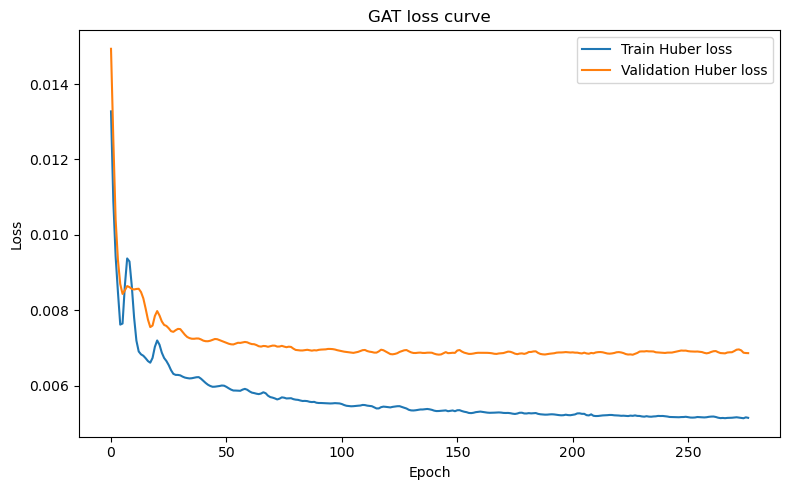

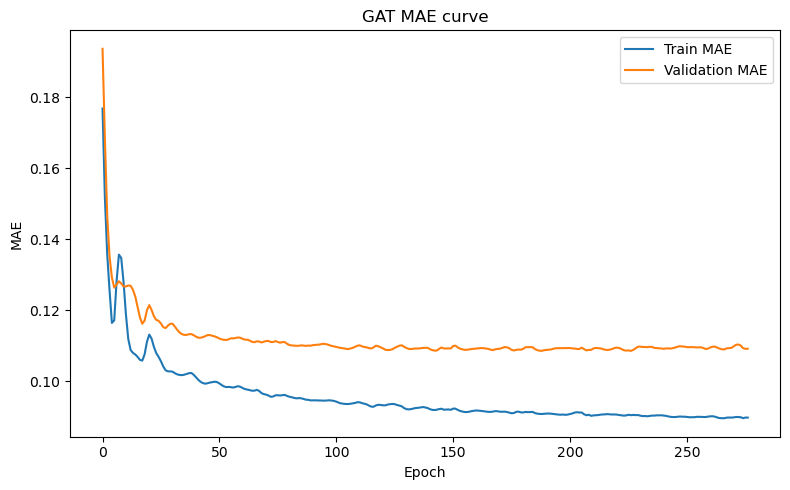

In [19]:
# 1. Loss curve

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Huber loss")
plt.plot(val_losses, label="Validation Huber loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAT loss curve")
plt.legend()
plt.tight_layout()
#plt.savefig(loss_curve_path, dpi=200, bbox_inches="tight")
#print(f"Saved to: {loss_curve_path}")
plt.show()

# 2. MAE curve

plt.figure(figsize=(8, 5))
plt.plot(train_maes, label="Train MAE")
plt.plot(val_maes, label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("GAT MAE curve")
plt.legend()
plt.tight_layout()
#plt.savefig(mae_curve_path, dpi=200, bbox_inches="tight")
#print(f"Saved to: {mae_curve_path}")
plt.show()

In [20]:

# Ablation: Self-loop-only GAT

def train_eval_gat_ablation(edge_index_used, label="GAT ablation"):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    ab_data = Data(
        x=x_tensor,
        edge_index=edge_index_used,
        y=y_tensor
    )
    ab_data.train_mask = train_mask
    ab_data.val_mask = val_mask
    ab_data.test_mask = test_mask
    ab_data = ab_data.to(device)

    model_ab = GATRegressor(
        in_dim=ab_data.x.shape[1],
        hidden_dim=64,
        heads=4,
        dropout=0.2
    ).to(device)

    optimizer_ab = torch.optim.Adam(
        model_ab.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    best_val_mae_ab = np.inf
    best_state_ab = None
    patience = 50
    wait = 0
    n_epochs = 300

    for epoch in range(1, n_epochs + 1):
        model_ab.train()
        optimizer_ab.zero_grad()

        out = model_ab(ab_data.x, ab_data.edge_index)

        loss = F.huber_loss(
            out[ab_data.train_mask],
            ab_data.y[ab_data.train_mask],
            delta=0.1
        )

        loss.backward()
        optimizer_ab.step()

        model_ab.eval()
        with torch.no_grad():
            pred = model_ab(ab_data.x, ab_data.edge_index)
            pred_np = pred.cpu().numpy()

            val_mae = mean_absolute_error(y_val, pred_np[val_idx])

        if val_mae < best_val_mae_ab:
            best_val_mae_ab = val_mae
            best_state_ab = {k: v.cpu().clone() for k, v in model_ab.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model_ab.load_state_dict(best_state_ab)
    model_ab = model_ab.to(device)
    model_ab.eval()

    with torch.no_grad():
        pred_all = model_ab(ab_data.x, ab_data.edge_index).cpu().numpy()

    pred_test = pred_all[test_idx]
    metrics = regression_metrics(y_test, pred_test)

    print(label)
    print("Best val MAE:", round(best_val_mae_ab, 4))
    print(metrics)

    return metrics, pred_all, best_val_mae_ab

In [21]:
# Create self-loop-only graph
n_nodes = len(lsoas_p)
self_nodes = torch.arange(n_nodes, dtype=torch.long)
edge_index_self_only = torch.stack([self_nodes, self_nodes], dim=0)

# Run ablation
self_gat_metrics, self_gat_pred_all, self_gat_best_val_mae = train_eval_gat_ablation(
    edge_index_self_only,
    label="Self-loop-only GAT"
)

Self-loop-only GAT
Best val MAE: 0.1079
{'MAE': 0.09826745092868805, 'RMSE': np.float64(0.12939041419047187), 'R2': 0.5340214967727661, 'Spearman': np.float64(0.7249521144731436)}


In [22]:
# Recompute Full Queen GAT test metrics
model.eval()

with torch.no_grad():
    gat_pred_all = model(data.x, data.edge_index).cpu().numpy()

gat_pred_test = gat_pred_all[test_idx]
gat_metrics = regression_metrics(y_test, gat_pred_test)

print(gat_metrics)

{'MAE': 0.09701818972826004, 'RMSE': np.float64(0.13000416643545287), 'R2': 0.529590368270874, 'Spearman': np.float64(0.7113969200260358)}


In [23]:
ablation_df = pd.DataFrame([
    {
        "model": "Full Queen GAT",
        "best_val_MAE": best_val_mae,
        **gat_metrics
    },
    {
        "model": "Self-loop-only GAT",
        "best_val_MAE": self_gat_best_val_mae,
        **self_gat_metrics
    }
])

ablation_df.round(4)

,model,best_val_MAE,MAE,RMSE,R2,Spearman
0,Full Queen GAT,0.1085,0.0970,0.1300,0.5296,0.7114
1,Self-loop-only GAT,0.1079,0.0983,0.1294,0.5340,0.7250


In [24]:
# Load the best GAT checkpoint and evaluate all models on the test set.

model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    gat_pred_all = model(data.x, data.edge_index).cpu().numpy()

gat_pred_test = gat_pred_all[test_idx]
gat_metrics = regression_metrics(y_test, gat_pred_test)

def fmt_metric(v):
    return "nan" if pd.isna(v) else f"{v:.4f}"

print("Evaluation on Test Set")
print(
    f"Mean Predictor  | "
    f"MAE={mean_metrics['MAE']:.4f} | "
    f"RMSE={mean_metrics['RMSE']:.4f} | "
    f"R2={mean_metrics['R2']:.4f} | "
    f"Spearman={fmt_metric(mean_metrics['Spearman'])}"
)
print(
    f"XGBoost         | "
    f"MAE={xgb_metrics['MAE']:.4f} | "
    f"RMSE={xgb_metrics['RMSE']:.4f} | "
    f"R2={xgb_metrics['R2']:.4f} | "
    f"Spearman={fmt_metric(xgb_metrics['Spearman'])}"
)
print(
    f"GAT (2-layer)   | "
    f"MAE={gat_metrics['MAE']:.4f} | "
    f"RMSE={gat_metrics['RMSE']:.4f} | "
    f"R2={gat_metrics['R2']:.4f} | "
    f"Spearman={fmt_metric(gat_metrics['Spearman'])}"
)

results_df = pd.DataFrame([
    {"model": "Mean Predictor", **mean_metrics},
    {"model": "XGBoost", **xgb_metrics},
    {"model": "GAT (2-layer)", **gat_metrics},
])

results_df

Evaluation on Test Set
Mean Predictor  | MAE=0.1606 | RMSE=0.1923 | R2=-0.0290 | Spearman=nan
XGBoost         | MAE=0.0995 | RMSE=0.1344 | R2=0.4973 | Spearman=0.7151
GAT (2-layer)   | MAE=0.0970 | RMSE=0.1300 | R2=0.5296 | Spearman=0.7114


,model,MAE,RMSE,R2,Spearman
0,Mean Predictor,0.160585,0.192277,-0.028997,NaN
1,XGBoost,0.099486,0.134387,0.497342,0.715095
2,GAT (2-layer),0.097018,0.130004,0.529590,0.711397


In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Full-London predictions from the trained GAT
model.eval()
with torch.no_grad():
    gat_pred_all = model(data.x, data.edge_index).cpu().numpy()

lsoas_plot = lsoas_p.to_crs(PLOT_CRS).copy()
lsoas_plot["y_true"] = y_raw
lsoas_plot["gat_pred"] = gat_pred_all
lsoas_plot["gat_residual"] = lsoas_plot["gat_pred"] - lsoas_plot["y_true"]

base_cmap = plt.colormaps.get_cmap("YlOrRd")
cols = base_cmap(np.linspace(0, 1, 256))
cols[:, :3] = cols[:, :3] * 0.80 + 1.0 * 0.20
soft_ylorrd = mcolors.LinearSegmentedColormap.from_list("soft_YlOrRd", cols)

base_div = plt.colormaps.get_cmap("RdBu_r")
cols_div = base_div(np.linspace(0, 1, 256))
cols_div[:, :3] = cols_div[:, :3] * 0.85 + 1.0 * 0.15
soft_rdbu = mcolors.LinearSegmentedColormap.from_list("soft_RdBu", cols_div)

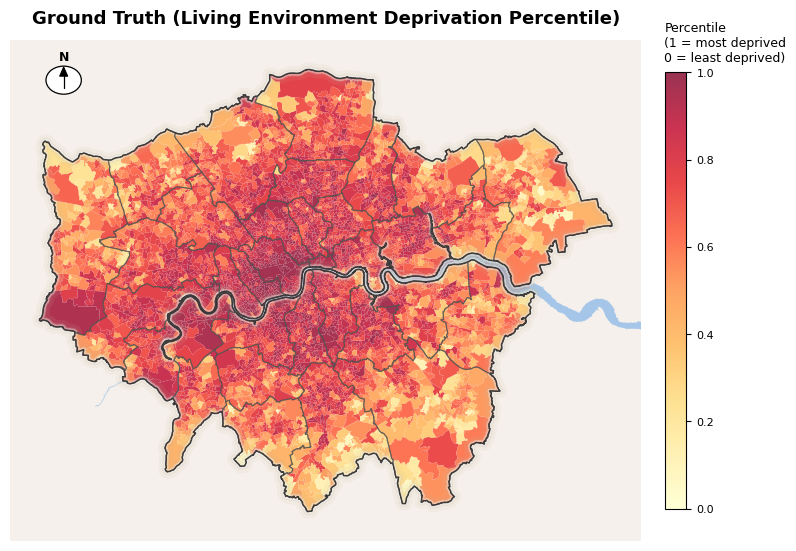

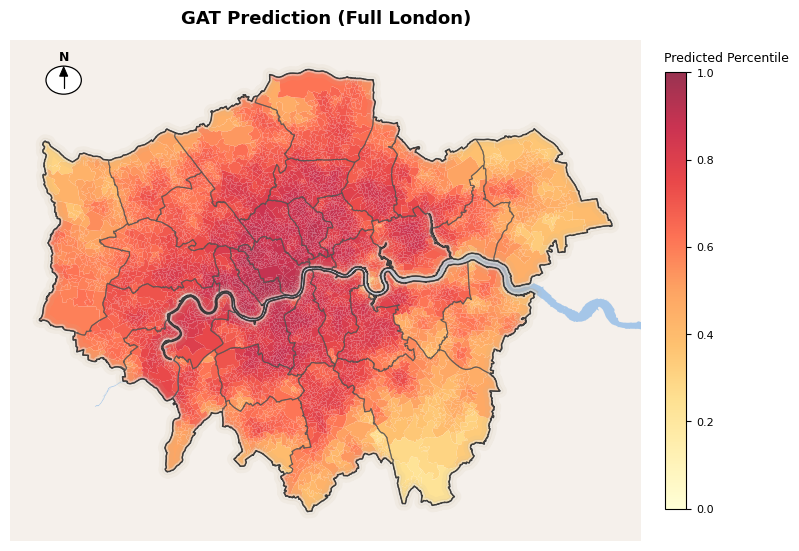

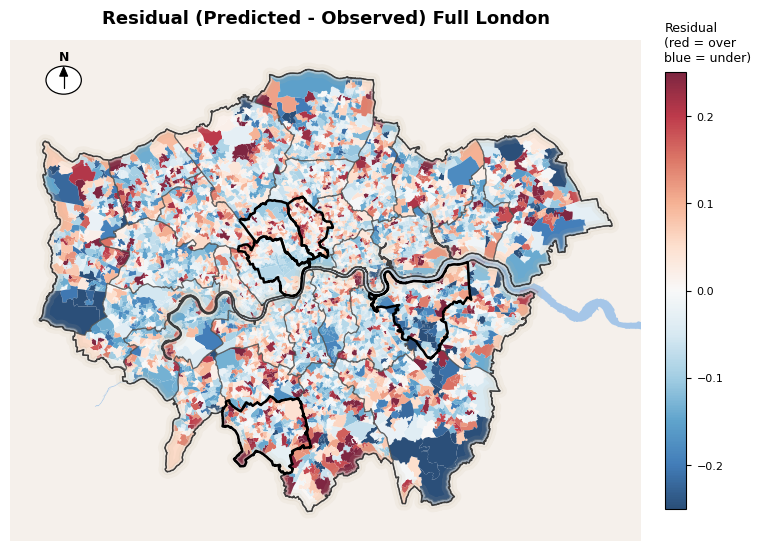

In [26]:
# Mapping

PLOT_CRS = "EPSG:27700"

borough = gpd.read_file( "Data/London_Borough.shp").to_crs(PLOT_CRS)
river = gpd.read_file( "Data/river.shp").to_crs(PLOT_CRS)
background = gpd.read_file( "Data/background_london.shp").to_crs(PLOT_CRS)

borough_diss = borough.dissolve(by="BOROUGHN", as_index=False)
london_outline = borough_diss.dissolve()
bg_outside = gpd.overlay(background, london_outline, how="difference")

# Full-London predictions from the trained GAT
model.eval()
with torch.no_grad():
    gat_pred_all = model(data.x, data.edge_index).cpu().numpy()

lsoas_plot = lsoas_p.to_crs(PLOT_CRS).copy()
lsoas_plot["y_true"] = y_raw
lsoas_plot["gat_pred"] = gat_pred_all
lsoas_plot["gat_residual"] = lsoas_plot["gat_pred"] - lsoas_plot["y_true"]

base_cmap = plt.colormaps.get_cmap("YlOrRd")
cols = base_cmap(np.linspace(0, 1, 256))
cols[:, :3] = cols[:, :3] * 0.80 + 1.0 * 0.20
soft_ylorrd = mcolors.LinearSegmentedColormap.from_list("soft_YlOrRd", cols)

base_div = plt.colormaps.get_cmap("RdBu_r")
cols_div = base_div(np.linspace(0, 1, 256))
cols_div[:, :3] = cols_div[:, :3] * 0.85 + 1.0 * 0.15
soft_rdbu = mcolors.LinearSegmentedColormap.from_list("soft_RdBu", cols_div)

# North Arrow
from matplotlib.patches import Circle, Polygon

def add_north_arrow(ax, x=0.085, y=0.92, r=0.028):
    """
    x, y: center of the north arrow in axes fraction
    r: ring radius
    """

    # Outer ring
    ring = Circle(
        (x, y),
        r,
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=20
    )
    ax.add_patch(ring)

    # Thin vertical shaft
    ax.plot(
        [x, x],
        [y - r * 0.55, y + r * 0.35],
        transform=ax.transAxes,
        color="black",
        linewidth=0.9,
        zorder=21,
        solid_capstyle="round"
    )

    # Arrow head
    head = Polygon(
        [
            (x, y + r * 0.95),
            (x - r * 0.23, y + r * 0.28),
            (x + r * 0.23, y + r * 0.28),
        ],
        closed=True,
        transform=ax.transAxes,
        facecolor="black",
        edgecolor="black",
        linewidth=0.7,
        zorder=22
    )
    ax.add_patch(head)

    # North label
    ax.text(
        x,
        y + r * 1.22,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black",
        zorder=23
    )


#  residual map
def highlight_boroughs(ax, borough_gdf, borough_names):
    sel = borough_gdf[borough_gdf["BOROUGHN"].isin(borough_names)].copy()

    sel.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.8,
        alpha=1.0,
        zorder=8
    )


def draw_map(ax, gdf, column, cmap, vmin, vmax, title, legend_title):
    xmin, ymin, xmax, ymax = london_outline.total_bounds
    pad = 3000

    bg_outside.plot(ax=ax, facecolor="#f5f0eb", edgecolor="black", linewidth=0.10, zorder=1)

    gdf.plot(
        column=column,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor="none",
        linewidth=0,
        legend=True,
        ax=ax,
        zorder=3,
        legend_kwds={"shrink": 0.45, "orientation": "vertical", "pad": 0.03}
    )

    river.plot(ax=ax, facecolor="#8BB9E8", edgecolor="none", linewidth=0, alpha=0.75, zorder=4)

    london_outline.boundary.plot(ax=ax, color="#c8b89a", linewidth=10, alpha=0.10, zorder=4.3)
    london_outline.boundary.plot(ax=ax, color="#c8b89a", linewidth=5, alpha=0.18, zorder=4.4)
    london_outline.boundary.plot(ax=ax, color="#f5f5f5", linewidth=3.5, alpha=0.40, zorder=4.8)
    london_outline.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.85, zorder=4.9)

    borough_diss.boundary.plot(
        ax=ax,
        color="#4f4f4f",
        linewidth=0.8,
        alpha=0.65,
        zorder=5
    )

    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_axis_off()

    add_north_arrow(ax)

    cax = ax.get_figure().axes[-1]
    cax.set_title(legend_title, fontsize=9, pad=8, loc="left")
    cax.title.set_x(1.5)
    cax.tick_params(labelsize=8, pad=4)


borough_names_to_highlight = [
    "Greenwich",
    "Sutton",
    "Islington",
    "Camden",
    "Westminster"
]

# 1. Ground truth map
fig, ax = plt.subplots(1, 1, figsize=(8, 10), facecolor="white")

draw_map(
    ax=ax,
    gdf=lsoas_plot,
    column="y_true",
    cmap=soft_ylorrd,
    vmin=0,
    vmax=1,
    title="Ground Truth (Living Environment Deprivation Percentile)",
    legend_title="Percentile\n(1 = most deprived\n0 = least deprived)"
)

plt.tight_layout()
#fig.savefig(truth_path, dpi=300, bbox_inches="tight", facecolor="white")
#print(f"Saved to: {truth_path}")
plt.show()

# 2. Prediction map
fig, ax = plt.subplots(1, 1, figsize=(8, 10), facecolor="white")

draw_map(
    ax=ax,
    gdf=lsoas_plot,
    column="gat_pred",
    cmap=soft_ylorrd,
    vmin=0,
    vmax=1,
    title="GAT Prediction (Full London)",
    legend_title="Predicted Percentile"
)

plt.tight_layout()
#fig.savefig(pred_path, dpi=300, bbox_inches="tight", facecolor="white")
#print(f"Saved to: {pred_path}")
plt.show()

# 3. Residual map
res_abs_max = round(np.abs(lsoas_plot["gat_residual"]).quantile(0.95), 2)

fig, ax = plt.subplots(1, 1, figsize=(8, 10), facecolor="white")

draw_map(
    ax=ax,
    gdf=lsoas_plot,
    column="gat_residual",
    cmap=soft_rdbu,
    vmin=-res_abs_max,
    vmax=res_abs_max,
    title="Residual (Predicted - Observed) Full London",
    legend_title="Residual\n(red = over\nblue = under)"
)

highlight_boroughs(ax, borough_diss, borough_names_to_highlight)

plt.tight_layout()
#fig.savefig(resid_path, dpi=300, bbox_inches="tight", facecolor="white")
#print(f"Saved to: {resid_path}")
plt.show()

In [27]:
analysis = lsoas_p.copy()

# full-London predictions
analysis["xgb_pred"] = xgb.predict(X_raw)

model.eval()
with torch.no_grad():
    analysis["gat_pred"] = model(data.x, data.edge_index).cpu().numpy()

# residuals
analysis["xgb_residual"] = analysis["xgb_pred"] - analysis["living_env_percentile"]
analysis["gat_residual"] = analysis["gat_pred"] - analysis["living_env_percentile"]
analysis["abs_xgb_error"] = np.abs(analysis["xgb_residual"])
analysis["abs_gat_error"] = np.abs(analysis["gat_residual"])

analysis[[
    "lsoa21cd",
    "lad22nm",
    "split",
    "living_env_percentile",
    "xgb_pred",
    "gat_pred",
    "abs_xgb_error",
    "abs_gat_error"
]].head()


,lsoa21cd,lad22nm,split,living_env_percentile,xgb_pred,gat_pred,abs_xgb_error,abs_gat_error
0,E01000011,Barking and Dagenham,train,0.963708,0.924106,0.760266,0.039602,0.203442
1,E01000046,Barking and Dagenham,train,0.579635,0.584180,0.627730,0.004545,0.048095
2,E01000051,Barking and Dagenham,train,0.688096,0.593956,0.658778,0.094140,0.029318
3,E01000077,Barking and Dagenham,train,0.777300,0.699259,0.657038,0.078041,0.120262
4,E01000083,Barking and Dagenham,train,0.796172,0.765355,0.657884,0.030817,0.138289


In [28]:
from sklearn.metrics import r2_score

rows = []

#  test borough
for borough_name, df_b in analysis[analysis["split"] == "test"].groupby("lad22nm"):
    y_true = df_b["living_env_percentile"].values
    y_gat  = df_b["gat_pred"].values

    rows.append({
        "lad22nm": borough_name,
        "n": len(df_b),
        "true_mean": y_true.mean(),
        "gat_mae": np.mean(np.abs(y_gat - y_true)),
        "gat_r2": r2_score(y_true, y_gat),
    })

borough_test_gat = (
    pd.DataFrame(rows)
    .sort_values("gat_mae", ascending=False)
    .reset_index(drop=True)
)

borough_test_gat = borough_test_gat.round({
    "true_mean": 3,
    "gat_mae": 3,
    "gat_r2": 3
})

borough_test_gat


,lad22nm,n,true_mean,gat_mae,gat_r2
0,Greenwich,164,0.632,0.123,0.226
1,Sutton,123,0.561,0.120,0.198
2,Islington,126,0.805,0.095,-0.237
3,Camden,130,0.857,0.070,0.060
4,Westminster,123,0.897,0.069,-0.159
